In [5]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/data")
pattern = re.compile(r"fold_(\d+)_(train|val|test)\.pkl$")
files = sorted([p for p in DATA_DIR.glob("fold_*_*.pkl") if pattern.match(p.name)])

print(f"Found {len(files)} fold files\n")

# --- Parameters ---
TARGET_VAL_PCT = 15.0  # Expected percentage size for Val
TARGET_TEST_PCT = 15.0  # Expected percentage size for Test
MIN_EPISODE_DAYS = 4.0  # Expected length of individual evaluation episodes
MIN_GAP_HOURS = 12.0  # Expected exclusion buffer around val/test episodes (h-block)
# ------------------

records = []
episode_warnings = []
eval_intervals = {}

for fp in files:
    m = pattern.match(fp.name)
    fold, split = int(m.group(1)), m.group(2)
    raw = pd.read_pickle(fp)

    if fold not in eval_intervals:
        eval_intervals[fold] = []

    # 1. Check Episode lengths and store intervals before concatenating
    if split in ["val", "test"] and isinstance(raw, list):
        for i, episode_df in enumerate(raw):
            if "Datetime" in episode_df.columns:
                dt_col = pd.to_datetime(episode_df["Datetime"])
                min_dt, max_dt = dt_col.min(), dt_col.max()

                # Store the exact start/end of this episode for the gap check
                eval_intervals[fold].append((min_dt, max_dt, split, i))

                # Calculate duration of this specific episode
                duration = max_dt - min_dt
                duration_days = duration.total_seconds() / (24 * 3600)

                # Check against rule (allowing -0.1 days for end-of-year cutoffs)
                if duration_days < (MIN_EPISODE_DAYS - 0.1):
                    episode_warnings.append(
                        f"Fold {fold} {split.upper()} episode {i} is only {duration_days:.2f} days long.")

    # 2. Convert to DataFrame (stitch episodes together)
    if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], pd.DataFrame):
        df = pd.concat(raw, ignore_index=True)
    elif isinstance(raw, pd.DataFrame):
        df = raw.copy()
    else:
        continue  # unsupported format

    if "Datetime" not in df.columns or "Imbalance Price" not in df.columns:
        continue

    out = pd.DataFrame({
        "datetime": pd.to_datetime(df["Datetime"], errors="coerce"),
        "price": pd.to_numeric(df["Imbalance Price"], errors="coerce"),
        "fold": fold,
        "split": split,
    }).dropna(subset=["datetime", "price"]).sort_values("datetime")

    records.append(out)

all_df = pd.concat(records, ignore_index=True).sort_values(["fold", "split", "datetime"])

# --- Verification & Output ---

# 1. Print Episode Size Warnings
if episode_warnings:
    print("⚠️  EPISODE LENGTH WARNINGS:")
    for w in episode_warnings:
        print("  - " + w)
else:
    print(f"✅ All Val/Test episodes are >= {MIN_EPISODE_DAYS} days long.")

# 2. Verify Exclusion Gaps (h-blocks)
gap_warnings = []
for fold in sorted(all_df["fold"].unique()):
    # Get all training datetimes mapping to this fold
    train_dts = all_df.loc[(all_df["fold"] == fold) & (all_df["split"] == "train"), "datetime"]

    for min_dt, max_dt, split, i in eval_intervals.get(fold, []):
        # A buffer zone of MIN_GAP_HOURS around the evaluation window
        forbidden_start = min_dt - pd.Timedelta(hours=MIN_GAP_HOURS)
        forbidden_end = max_dt + pd.Timedelta(hours=MIN_GAP_HOURS)

        # Check if train data leaked into the exclusion buffer
        violations = train_dts[(train_dts > forbidden_start) & (train_dts < forbidden_end)]
        if len(violations) > 0:
            gap_warnings.append(
                f"Fold {fold} {split.upper()} episode {i} has {len(violations)} train records inside the {MIN_GAP_HOURS}h buffer!")

if gap_warnings:
    print("\n⚠️  BUFFER GAP LEAKAGE WARNINGS:")
    for w in gap_warnings:
        print("  - " + w)
else:
    print(f"✅ All Val/Test episodes correctly maintain a >= {MIN_GAP_HOURS} hour gap from Training data.")

# 3. Verify Sizes against targets
print("\n--- Data Size Ratios (per fold) ---")
for fold in sorted(all_df["fold"].unique()):
    sizes = {s: len(all_df[(all_df["fold"] == fold) & (all_df["split"] == s)]) for s in ["train", "val", "test"]}
    total = sum(sizes.values())

    val_pct = (sizes["val"] / total) * 100 if total > 0 else 0
    test_pct = (sizes["test"] / total) * 100 if total > 0 else 0
    train_pct = (sizes["train"] / total) * 100 if total > 0 else 0

    print(
        f"Fold {fold}: Train {train_pct:.1f}% | Val {val_pct:.1f}% (Target: {TARGET_VAL_PCT}%) | Test {test_pct:.1f}% (Target: {TARGET_TEST_PCT}%)")



Found 15 fold files

⚠️  EPISODE LENGTH WARNINGS:
  - Fold 0 TEST episode 0 is only 3.08 days long.
  - Fold 4 VAL episode 24 is only 3.08 days long.
✅ All Val/Test episodes correctly maintain a >= 12.0 hour gap from Training data.

--- Data Size Ratios (per fold) ---
Fold 0: Train 69.5% | Val 15.3% (Target: 15.0%) | Test 15.1% (Target: 15.0%)
Fold 1: Train 69.3% | Val 15.4% (Target: 15.0%) | Test 15.3% (Target: 15.0%)
Fold 2: Train 69.3% | Val 15.4% (Target: 15.0%) | Test 15.4% (Target: 15.0%)
Fold 3: Train 69.3% | Val 15.3% (Target: 15.0%) | Test 15.4% (Target: 15.0%)
Fold 4: Train 69.5% | Val 15.2% (Target: 15.0%) | Test 15.3% (Target: 15.0%)


In [6]:
import pandas as pd

def analyze_split_overlaps(all_df: pd.DataFrame):
    """
    Analyzes all_df to find duplicate timestamps across different splits and folds.
    """
    print("--- Starting Cross-Fold Overlap Analysis ---")

    # 1. Internal Overlap Check (Within the same fold)
    internal_overlaps = []
    for fold in sorted(all_df["fold"].unique()):
        fold_data = all_df[all_df["fold"] == fold]
        # Check if the same datetime appears in more than one split within this fold
        duplicates = fold_data[fold_data.duplicated(subset=["datetime"], keep=False)]

        if not duplicates.empty:
            # Group by datetime to see which splits are colliding
            collision_counts = duplicates.groupby("datetime")["split"].unique()
            internal_overlaps.append(f"Fold {fold}: {len(collision_counts)} timestamps assigned to multiple splits (e.g., {collision_counts.iloc[0]})")

    # 2. Cross-Test Overlap Check (Are Test sets unique across folds?)
    test_only = all_df[all_df["split"] == "test"]
    test_duplicates = test_only[test_only.duplicated(subset=["datetime"], keep=False)]

    # 3. Cross-Val Overlap Check (Are Val sets unique across folds?)
    val_only = all_df[all_df["split"] == "val"]
    val_duplicates = val_only[val_only.duplicated(subset=["datetime"], keep=False)]

    # --- Print Results ---

    if not internal_overlaps:
        print("✅ Success: No split overlaps found within any individual fold.")
    else:
        print("⚠️  INTERNAL OVERLAP WARNINGS:")
        for warning in internal_overlaps:
            print(f"  - {warning}")

    if test_duplicates.empty:
        print("✅ Success: All Test sets are unique across all folds.")
    else:
        # Calculate how many timestamps are shared
        shared_test_count = test_duplicates["datetime"].nunique()
        print(f"❌ ERROR: {shared_test_count} timestamps are shared between different Test folds.")

    if val_duplicates.empty:
        print("✅ Success: All Validation sets are unique across all folds.")
    else:
        shared_val_count = val_duplicates["datetime"].nunique()
        print(f"ℹ️  INFO: {shared_val_count} timestamps are shared between different Validation folds.")

# Run the analysis
analyze_split_overlaps(all_df)

--- Starting Cross-Fold Overlap Analysis ---
✅ Success: No split overlaps found within any individual fold.
✅ Success: All Test sets are unique across all folds.
✅ Success: All Validation sets are unique across all folds.


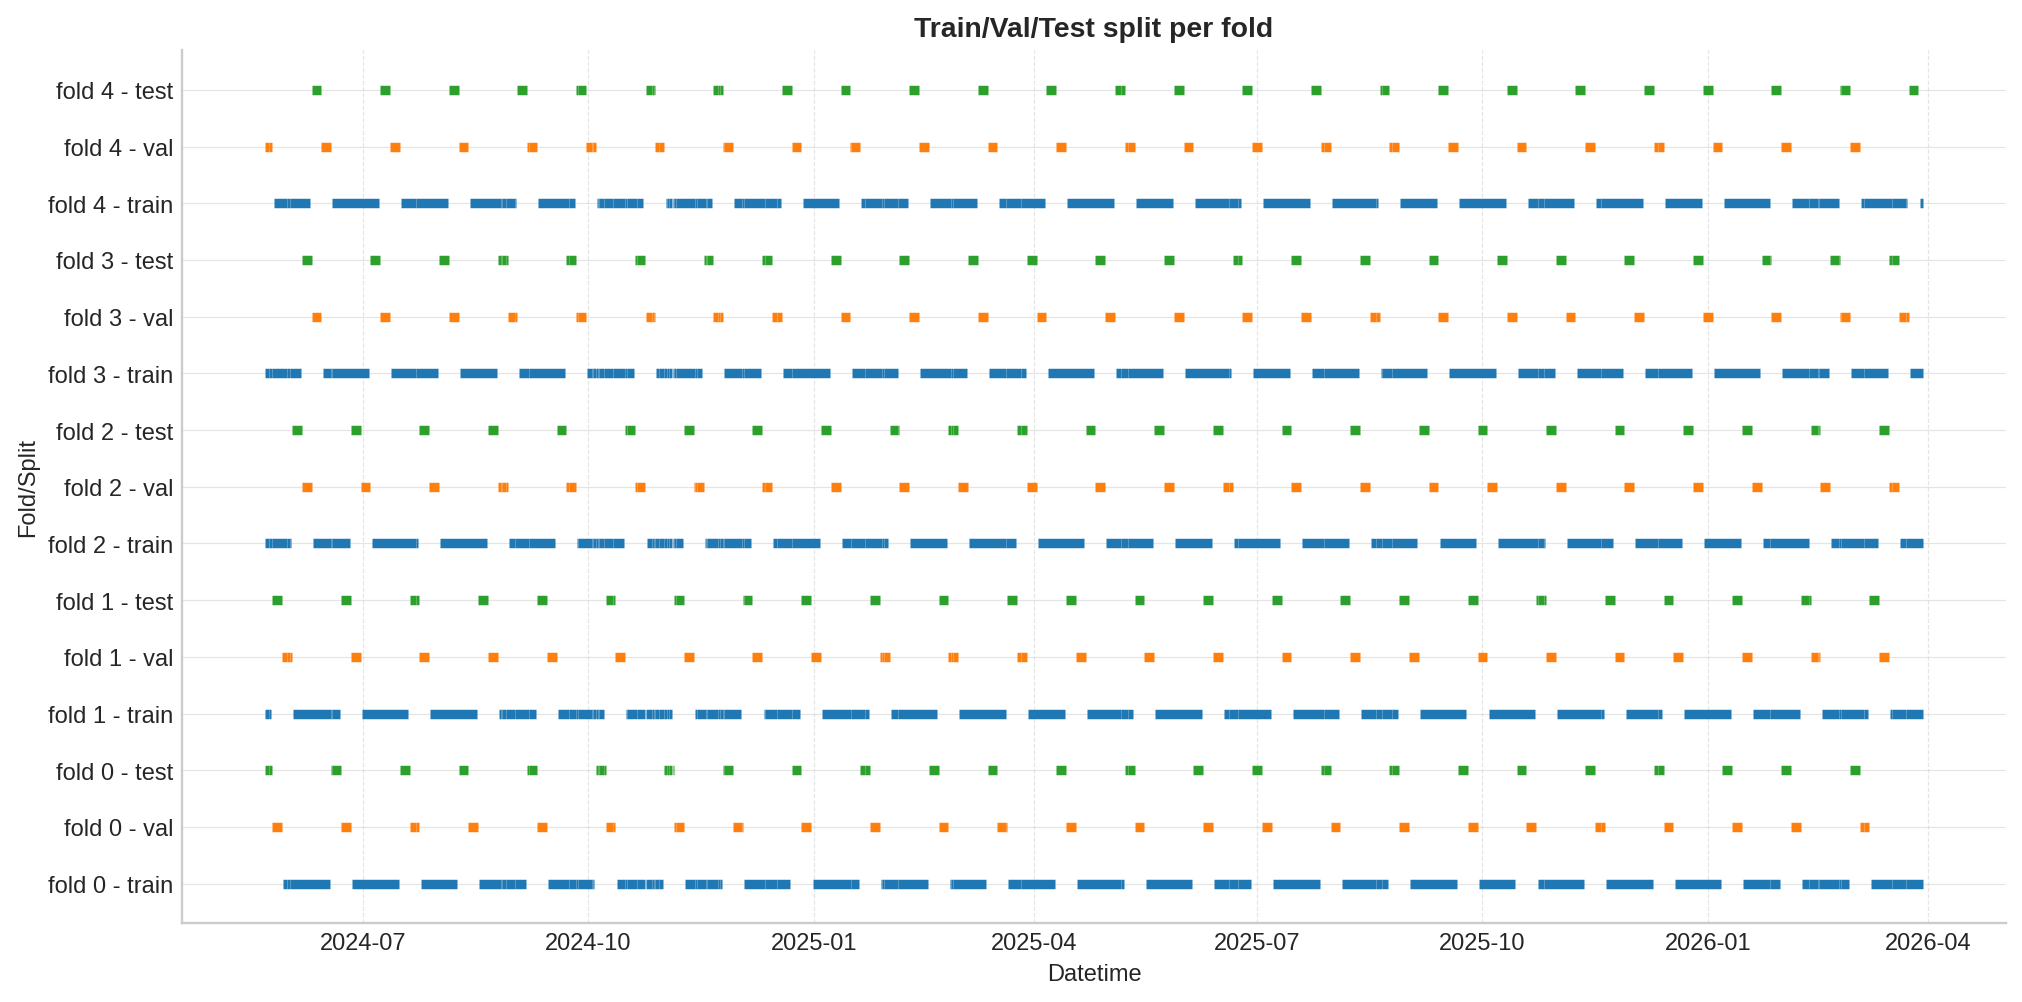

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 6), dpi=170)

# Define order and colors
order = []
for fold in sorted(all_df["fold"].unique()):
    for split in ["train", "val", "test"]:
        order.append((fold, split))

y_map = {k: i for i, k in enumerate(order)}
colors = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#2ca02c"}

# Define a threshold to identify gaps (e.g., 15 minutes)
gap_threshold = pd.Timedelta(minutes=15)

for (fold, split), g in all_df.groupby(["fold", "split"]):
    y = y_map[(fold, split)]

    # Sort group by datetime to find gaps
    g = g.sort_values("datetime")

    # Identify where a new segment starts (where time diff > threshold)
    g["diff"] = g["datetime"].diff()
    new_segment_indices = np.where(g["diff"] > gap_threshold)[0]

    # Calculate start and end indices of each continuous block
    starts = [0] + list(new_segment_indices)
    ends = list(new_segment_indices - 1) + [len(g) - 1]

    # Draw each segment individually
    for start_idx, end_idx in zip(starts, ends):
        start_dt = g.iloc[start_idx]["datetime"]
        end_dt = g.iloc[end_idx]["datetime"]

        ax.hlines(y, start_dt, end_dt, color=colors[split], lw=4)

# Formatting
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"fold {f} - {s}" for (f, s) in order])
ax.set_title("Train/Val/Test split per fold", weight="bold")
ax.set_xlabel("Datetime")
ax.set_ylabel("Fold/Split")
ax.grid(True, axis="x", ls="--", alpha=0.5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.savefig("split_per_fol.png", dpi=600, bbox_inches="tight")
plt.show()

In [8]:

from scipy.stats import skew, kurtosis

rows = []
for (fold, split), g in all_df.groupby(["fold", "split"]):
    p = g["price"].values
    rows.append({
        "Fold": fold,
        "Split": split,
        "N": len(p),
        "Mean": np.mean(p),
        "Std": np.std(p, ddof=1),
        "Median": np.median(p),
        "Q25": np.percentile(p, 25),
        "Q75": np.percentile(p, 75),
        "Skewness": skew(p),
        "Kurtosis": kurtosis(p),
    })

stats_df = pd.DataFrame(rows).sort_values(["Split", "Fold"])
stats_df["IQR"] = stats_df["Q75"] - stats_df["Q25"]

# Show per-split summary: how consistent are folds?
print("=== Per-split consistency across folds ===")
for split in ["train", "val", "test"]:
    sub = stats_df[stats_df["Split"] == split]
    print(f"\n{split.upper()}:")
    print(
        f"  Mean  range: {sub['Mean'].min():.2f} – {sub['Mean'].max():.2f}  (spread {sub['Mean'].max() - sub['Mean'].min():.2f})")
    print(f"  Std   range: {sub['Std'].min():.2f} – {sub['Std'].max():.2f}")
    print(f"  IQR   range: {sub['IQR'].min():.2f} – {sub['IQR'].max():.2f}")

display(stats_df.round(2))


=== Per-split consistency across folds ===

TRAIN:
  Mean  range: 75.82 – 79.17  (spread 3.35)
  Std   range: 149.00 – 154.61
  IQR   range: 94.77 – 103.15

VAL:
  Mean  range: 71.64 – 85.34  (spread 13.70)
  Std   range: 141.15 – 161.19
  IQR   range: 86.16 – 109.13

TEST:
  Mean  range: 70.66 – 82.09  (spread 11.43)
  Std   range: 147.78 – 162.79
  IQR   range: 89.72 – 105.40


,Fold,Split,N,Mean,Std,Median,Q25,Q75,Skewness,Kurtosis,IQR
0,0,test,141713,82.09,162.79,87.40,41.62,142.51,2.44,68.74,100.90
3,1,test,143611,75.50,151.25,87.00,35.50,140.90,-1.56,8.59,105.40
6,2,test,143796,79.34,147.78,82.09,41.28,131.00,0.31,24.00,89.72
9,3,test,143700,70.66,159.41,82.02,32.06,130.87,-0.67,13.71,98.81
12,4,test,143263,72.92,154.86,81.90,30.25,129.57,-0.76,13.16,99.32
1,0,train,650898,75.82,150.66,84.00,35.02,133.12,-0.87,14.54,98.10
4,1,train,648350,77.15,154.61,85.42,35.50,136.01,-0.04,28.35,100.51
7,2,train,648084,75.91,153.94,85.08,33.19,136.34,-0.38,26.46,103.15
10,3,train,648742,79.17,149.14,85.06,40.00,134.77,0.05,31.21,94.77
13,4,train,649305,76.05,149.00,84.50,36.15,134.61,-0.97,13.79,98.46


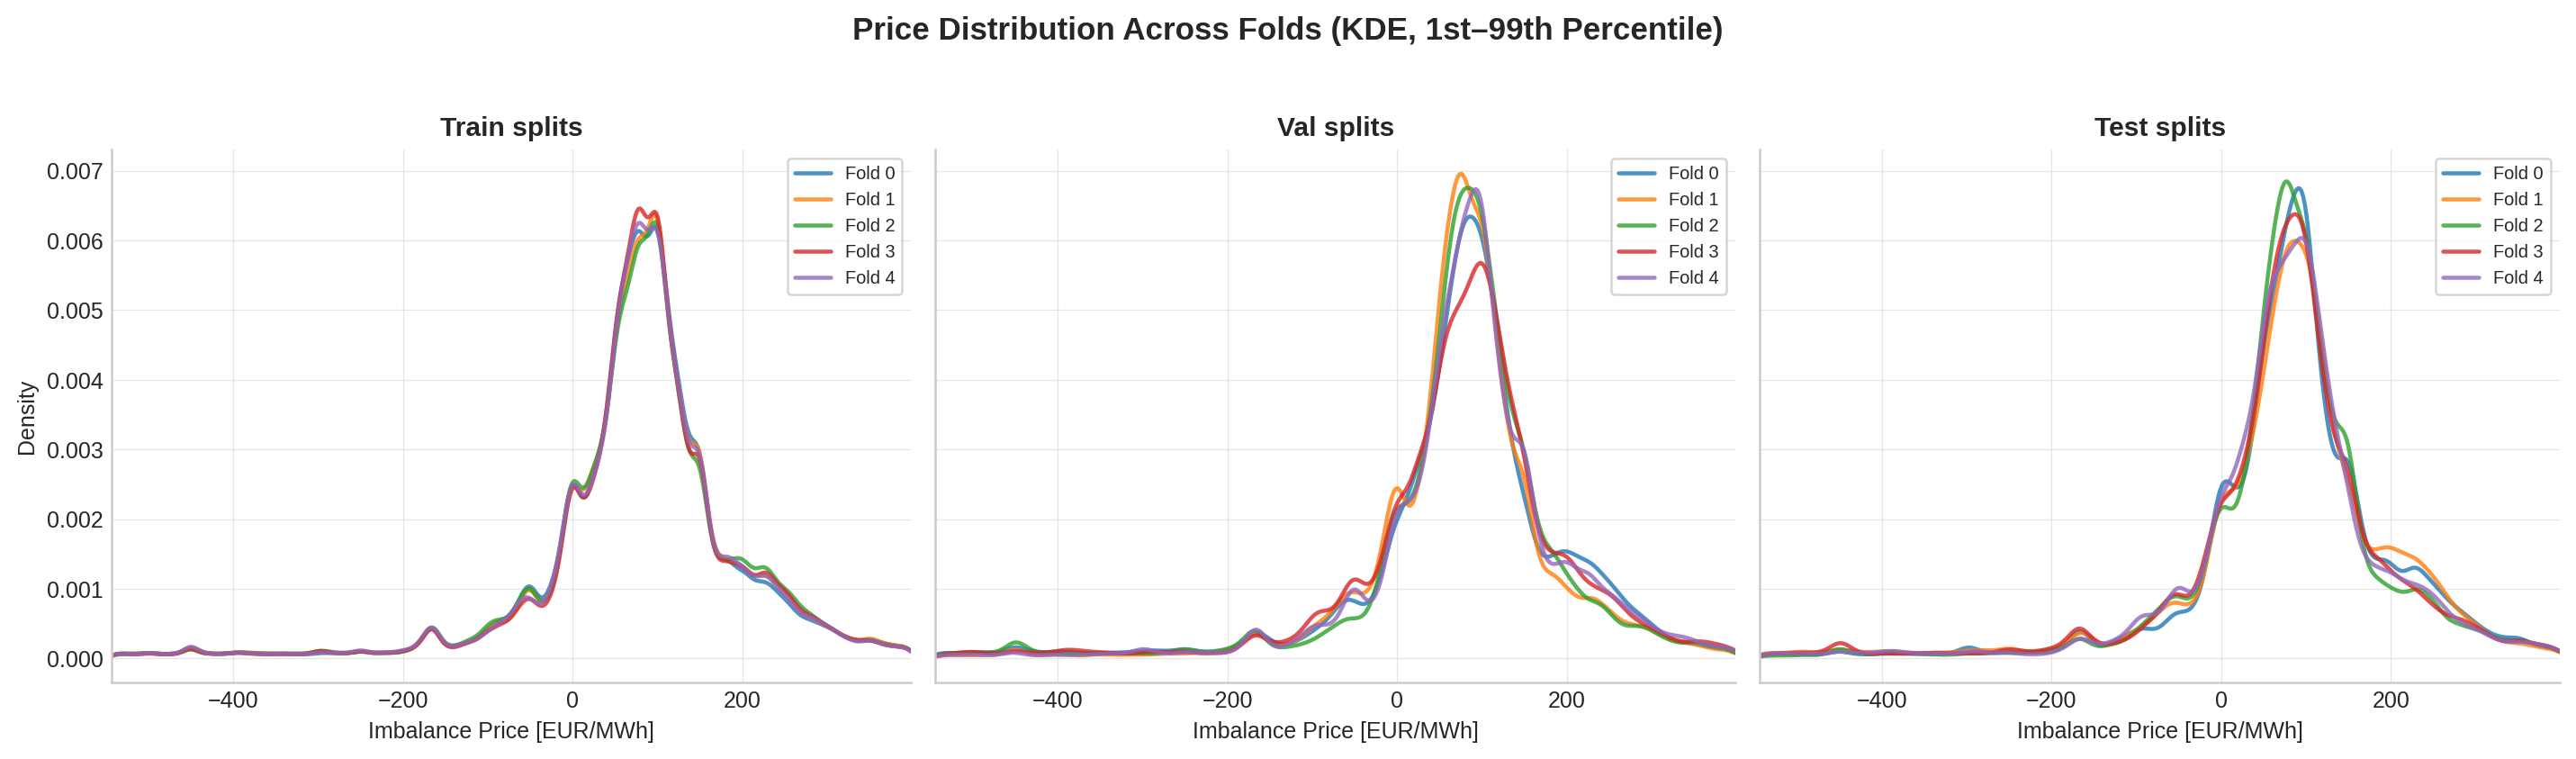

Saved: kde_across_folds.png


In [9]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=180, sharey=True)
plt.style.use("seaborn-v0_8-whitegrid")

# Clip to 1st-99th percentile for readable KDEs
q_low, q_high = all_df["price"].quantile([0.01, 0.99])

fold_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for ax, split in zip(axes, ["train", "val", "test"]):
    for fold in sorted(all_df["fold"].unique()):
        prices = all_df[(all_df["fold"] == fold) & (all_df["split"] == split)]["price"]
        prices_clipped = prices[(prices >= q_low) & (prices <= q_high)]
        prices_clipped.plot.kde(ax=ax, label=f"Fold {fold}", color=fold_colors[fold], lw=1.8, alpha=0.8)

    ax.set_title(f"{split.capitalize()} splits", fontsize=12, weight="bold")
    ax.set_xlabel("Imbalance Price [EUR/MWh]")
    ax.legend(fontsize=8, frameon=True)
    ax.set_xlim(q_low, q_high)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Density")
fig.suptitle("Price Distribution Across Folds (KDE, 1st–99th Percentile)", fontsize=14, weight="bold", y=1.03)
fig.tight_layout()
fig.savefig("kde_across_folds.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: kde_across_folds.png")


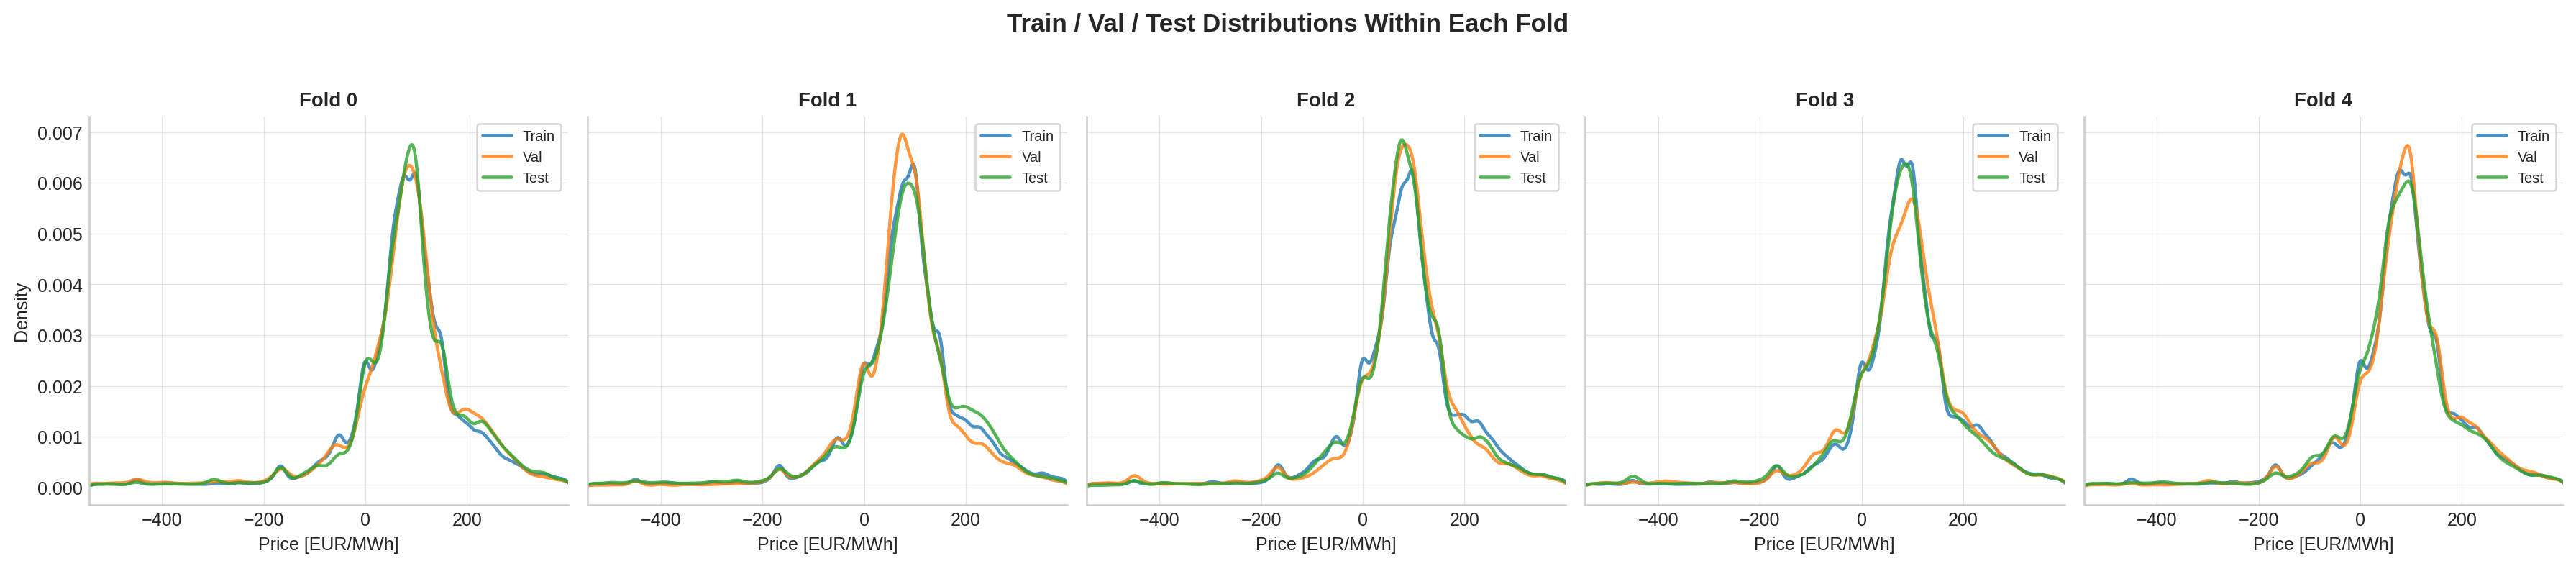

Saved: kde_within_folds.png


In [10]:


split_colors = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#2ca02c"}
n_folds = all_df["fold"].nunique()

fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 4.2), dpi=180, sharey=True, sharex=True)
plt.style.use("seaborn-v0_8-whitegrid")

q_low, q_high = all_df["price"].quantile([0.01, 0.99])

for ax, fold in zip(axes, sorted(all_df["fold"].unique())):
    for split in ["train", "val", "test"]:
        prices = all_df[(all_df["fold"] == fold) & (all_df["split"] == split)]["price"]
        prices_clipped = prices[(prices >= q_low) & (prices <= q_high)]
        prices_clipped.plot.kde(ax=ax, label=split.capitalize(), color=split_colors[split], lw=1.8, alpha=0.8)

    ax.set_title(f"Fold {fold}", fontsize=11, weight="bold")
    ax.set_xlabel("Price [EUR/MWh]")
    ax.set_xlim(q_low, q_high)
    ax.legend(fontsize=8, frameon=True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Density")
fig.suptitle("Train / Val / Test Distributions Within Each Fold", fontsize=14, weight="bold", y=1.03)
fig.tight_layout()
fig.savefig("kde_within_folds.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: kde_within_folds.png")


In [ ]:

from scipy.stats import ks_2samp, levene, wasserstein_distance

test_rows = []

# A) WITHIN each fold: train vs val, train vs test, val vs test
for fold in sorted(all_df["fold"].unique()):
    split_data = {
        s: all_df[(all_df["fold"] == fold) & (all_df["split"] == s)]["price"].values
        for s in ["train", "val", "test"]
    }
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        xa, xb = split_data[a], split_data[b]
        ks_stat, ks_p = ks_2samp(xa, xb)
        lev_stat, lev_p = levene(xa, xb, center="median")
        wd = wasserstein_distance(xa, xb)
        test_rows.append({
            "Scope": "Within fold",
            "Fold": fold,
            "Comparison": f"{a} vs {b}",
            "KS Stat": ks_stat,
            "KS p-value": ks_p,
            "Wasserstein": wd,
            "Levene p-value": lev_p,
        })

# B) ACROSS folds for each split: are all 5 train sets similar? etc.
from itertools import combinations

for split in ["train", "val", "test"]:
    fold_arrays = {
        f: all_df[(all_df["fold"] == f) & (all_df["split"] == split)]["price"].values
        for f in sorted(all_df["fold"].unique())
    }
    for (f1, x1), (f2, x2) in combinations(fold_arrays.items(), 2):
        ks_stat, ks_p = ks_2samp(x1, x2)
        wd = wasserstein_distance(x1, x2)
        test_rows.append({
            "Scope": "Across folds",
            "Fold": f"{f1} vs {f2}",
            "Comparison": f"{split}",
            "KS Stat": ks_stat,
            "KS p-value": ks_p,
            "Wasserstein": wd,
            "Levene p-value": np.nan,
        })

test_df = pd.DataFrame(test_rows)

print("=== WITHIN-FOLD tests (train/val/test similarity) ===")
display(test_df[test_df["Scope"] == "Within fold"].round(4))

print("\n=== ACROSS-FOLD tests (fold-to-fold similarity for same split) ===")
display(test_df[test_df["Scope"] == "Across folds"].round(4))


In [ ]:

import seaborn as sns
import calendar

tmp = all_df.copy()
tmp["month"] = tmp["datetime"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=180)
plt.style.use("seaborn-v0_8-whitegrid")

for ax, split in zip(axes, ["train", "val", "test"]):
    sub = tmp[tmp["split"] == split]
    month_counts = sub.groupby(["fold", "month"]).size().reset_index(name="count")
    # Normalise: fraction of each fold's data per month
    totals = month_counts.groupby("fold")["count"].transform("sum")
    month_counts["frac"] = month_counts["count"] / totals

    mat = month_counts.pivot(index="fold", columns="month", values="frac").reindex(columns=range(1, 13))
    mat.columns = [calendar.month_abbr[m] for m in range(1, 13)]

    sns.heatmap(mat, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                linewidths=0.5, vmin=0, vmax=mat.max().max() * 1.15)
    ax.set_title(f"{split.capitalize()}", fontsize=12, weight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Fold" if split == "train" else "")

fig.suptitle("Monthly Composition per Fold and Split (Fraction of Rows)", fontsize=14, weight="bold", y=1.03)
fig.tight_layout()
fig.savefig("month_composition_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: month_composition_heatmap.png")
